In [1]:
import numpy as np
import pandas as pd

import matplotlib
import shutil

# Manually configure the path to the LaTeX executable from your conda env
# Note: You might need to adjust the path slightly based on your installation
latex_path = shutil.which("latex") # This finds latex in your current PATH

if latex_path:
    matplotlib.rcParams['text.latex.preamble'] = ''
    matplotlib.rcParams['text.usetex'] = True
    matplotlib.rcParams['pgf.texsystem'] = 'pdflatex'
    matplotlib.rcParams['pgf.rcfonts'] = False
    matplotlib.rcParams['pgf.preamble'] = ''
    # Point to the TeX programs in the same directory
    matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    print("✅ Matplotlib's LaTeX path has been configured.")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("notebook", font_scale=1.25)

✅ Matplotlib's LaTeX path has been configured.


In [2]:
def set_axis_fine_ticks(ax: plt.Axes):
    ax.minorticks_on()
    ax.grid(which='major', linestyle='-', linewidth='0.5', color='grey')
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='darkgrey')

In [3]:
df = pd.read_csv('benchmark.csv')

# ADD VIRTUAL ROWS FOR V6 higher params
v6k0 = df.query('(version in ["V6", "V0"]) & (test == "k0")')[['date', 'seed', 'version', 'device', 'exetime']].rename(columns={'exetime': 'exetime_one'})
v8k0 = df.query('(version == "V8") & (test == "k0") & (val != 1)')
merged = v8k0.merge(v6k0, on=['date', 'seed', 'device'], how='right').rename(columns={'version_y': 'version'})
merged['exetime'] = merged['exetime_one'] * merged['val']
merged.drop(columns=['exetime_one', 'version_x'], inplace=True)
# merged
df = pd.concat([df, merged])

df['exetime'] /= 60

df = df.sort_values(['device', 'date', 'seed', 'val', 'version']).copy().reset_index(drop=True)
df

,date,seed,test,val,version,device,exetime,power
0,20111116,72,k0,1,V0,A100,15.651023,201492.864
1,20111116,72,k0,1,V8,A100,0.186767,4211.259
2,20111116,72,k0,2,V0,A100,31.302046,7782.444
3,20111116,72,k0,2,V8,A100,0.322197,7782.444
4,20111116,72,k0,4,V0,A100,62.604093,15341.953
...,...,...,...,...,...,...,...,...
8059,20180929,861,part,4096,V8,RTX 3090,0.077508,3148.876
8060,20180929,861,part,8192,V8,RTX 3090,0.134855,5609.753
8061,20180929,861,part,16384,V8,RTX 3090,0.260402,10702.601
8062,20180929,861,part,32768,V8,RTX 3090,0.514563,21156.359


In [4]:
for d in df['date'].unique():
    print(d, df.query(f'(date == {d}) & (test == "k0") & (device == "A40")')['exetime'].sum() / 60 / 60)

20111116 7.44459246851007
20140917 5.212886673810306
20150907 5.269175068365202
20160827 4.033197907549363
20170623 3.4507884145511523
20180929 3.1802970861196522


In [5]:
df['date'].unique()

array([20111116, 20140917, 20150907, 20160827, 20170623, 20180929])

In [6]:
# df.query('(test == "k0") & (val >= 64) & (version == "V8") & (device == "A40") & (date > 20140917)')['exetime'].sum()/60

In [7]:
# TEMPORARY DROP RTX 3090 HIGH PARAMS
# df = df.drop(df.query('(device == "RTX 3090") & (test == "k0") & (val in [64, 128])').index)

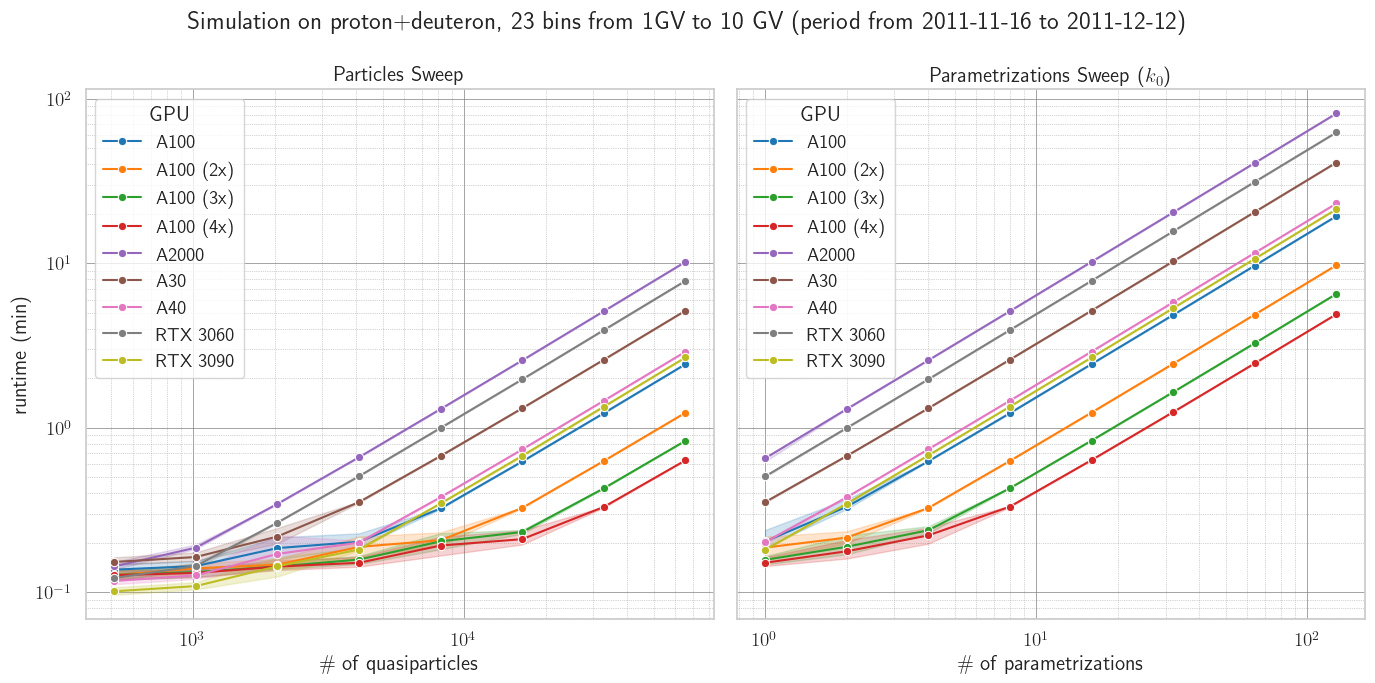

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7), tight_layout=True, sharey=True)
fig.suptitle('Simulation on proton+deuteron, 23 bins from 1GV to 10 GV (period from 2011-11-16 to 2011-12-12)')

ax1 = sns.lineplot(
    data=df.query('(version == "V8") & (test == "part") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[0],
)
ax1.get_legend().set_title('GPU')
ax1.set(title='Particles Sweep', xscale='log', yscale='log', xlabel=r'\# of quasiparticles', ylabel='runtime (min)')
set_axis_fine_ticks(ax1)

ax2 = sns.lineplot(
    data=df.query('(version == "V8") & (test == "k0") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[1],
)
ax2.get_legend().set_title('GPU')
ax2.set(title='Parametrizations Sweep ($k_0$)', xscale='log', yscale='log', xlabel=r'\# of parametrizations', ylabel='runtime (min)')
set_axis_fine_ticks(ax2)

[None, None, Text(0.5, 0, '\\# param'), Text(0, 0.5, 'time (s)')]

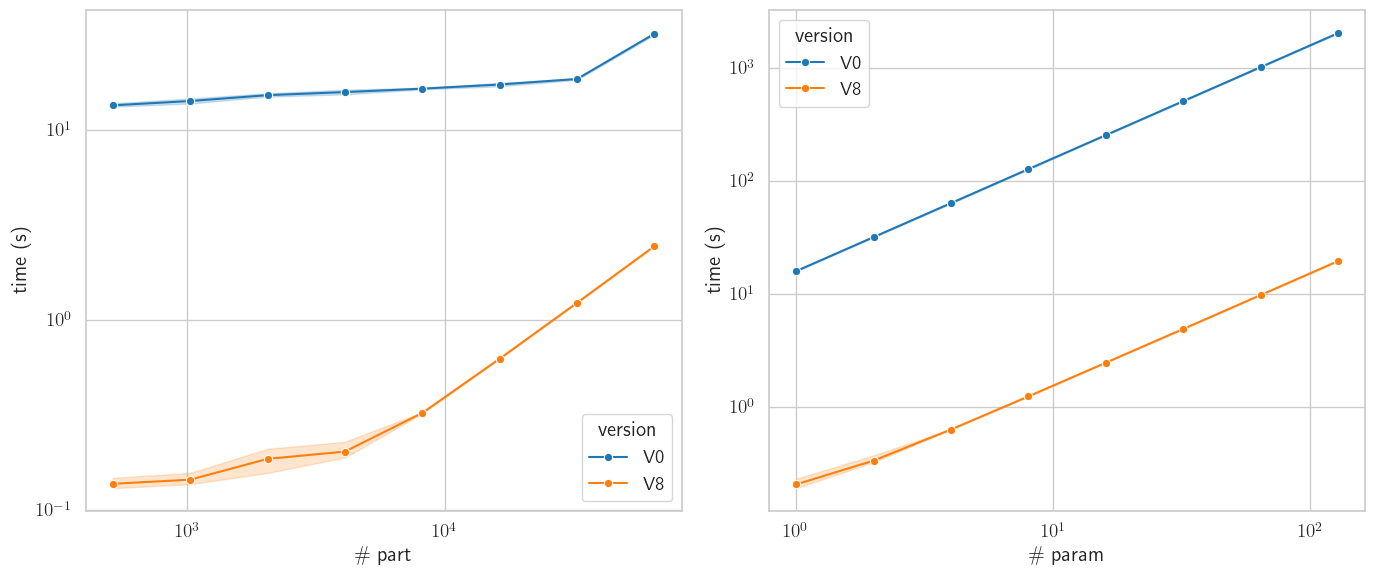

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.lineplot(
    data=df.query('(device == "A100") & (test == "part") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='version',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[0],
)
ax1.set(xscale='log', yscale='log', xlabel=r'\# part', ylabel='time (s)')

ax2 = sns.lineplot(
    data=df.query('(device == "A100") & (test == "k0") & (date == 20111116)'),
    x='val',
    y='exetime',
    hue='version',
    marker='o',
    errorbar=('ci', 100),
    ax=ax[1],
)
ax2.set(xscale='log', yscale='log', xlabel=r'\# param', ylabel='time (s)')

[Text(0.5, 1.0, 'Parametrizations Sweep ($k_0$)'),
 None,
 Text(0.5, 0, '\\# of parametrizations'),
 Text(0, 0.5, 'speedups (x times)')]

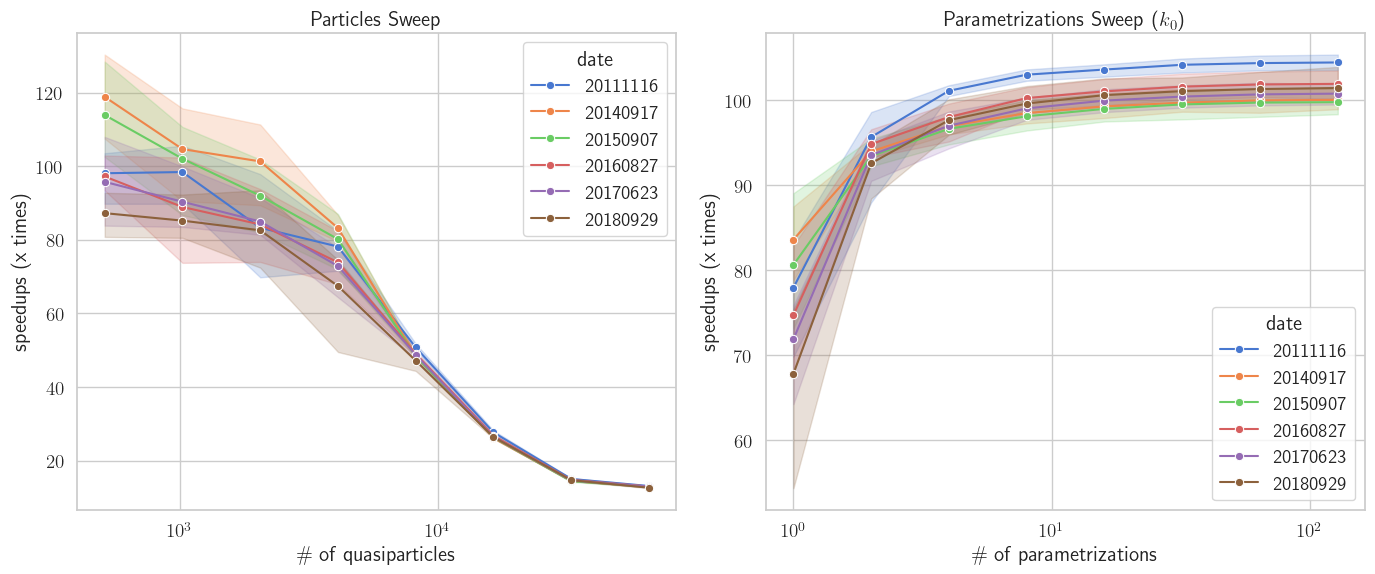

In [10]:
df_ = pd.merge(
    df.query('(device == "A100") & (version == "V0")'),
    df.query('(device == "A100") & (version == "V8")'),
    on=['date', 'seed', 'test', 'val', 'device'],
)
df_['ratio'] = df_['exetime_x'] / df_['exetime_y']

fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.lineplot(
    data=df_.query('test == "part"'),
    x='val',
    y='ratio',
    hue='date',
    marker='o',
    errorbar=('ci', 100),
    palette='muted',
    ax=ax[0],
)
ax1.set(title='Particles Sweep', xscale='log', xlabel=r'\# of quasiparticles', ylabel='speedups (x times)')

ax2 = sns.lineplot(
    data=df_.query('test == "k0"'),
    x='val',
    y='ratio',
    hue='date',
    marker='o',
    errorbar=('ci', 100),
    palette='muted',
    ax=ax[1],
)
ax2.set(title='Parametrizations Sweep ($k_0$)', xscale='log', xlabel=r'\# of parametrizations', ylabel='speedups (x times)')

In [11]:
df_.query('(test == "k0") & (val == 4) & (date == 20150907)')

,date,seed,test,val,version_x,device,exetime_x,power_x,version_y,exetime_y,power_y,ratio
194,20150907,72,k0,4,V0,A100,40.192801,10413.827,V8,0.415340,10413.827,96.770881
210,20150907,103,k0,4,V0,A100,40.147270,10412.891,V8,0.413891,10412.891,96.999539
226,20150907,107,k0,4,V0,A100,39.621027,10385.202,V8,0.415307,10385.202,95.401749
242,20150907,271,k0,4,V0,A100,41.056217,10383.830,V8,0.416679,10383.830,98.532010
258,20150907,436,k0,4,V0,A100,39.457019,10434.501,V8,0.417420,10434.501,94.525829
274,20150907,861,k0,4,V0,A100,40.696234,10439.354,V8,0.416622,10439.354,97.681467


<Axes: xlabel='device', ylabel='power'>

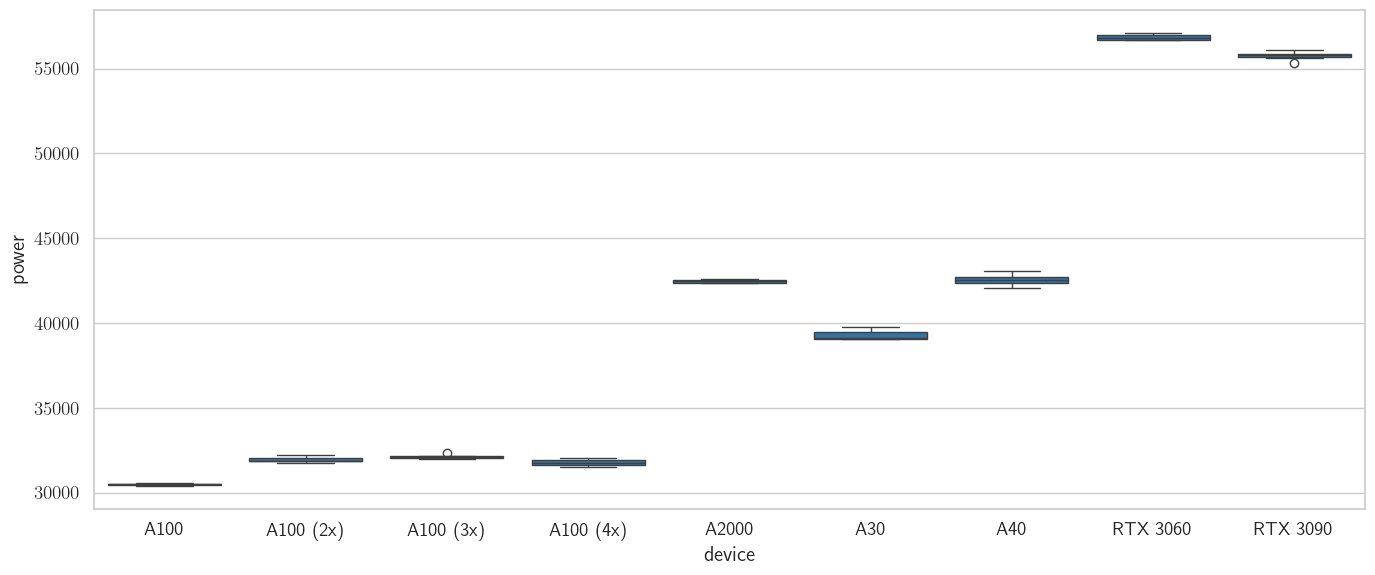

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(14, 6), tight_layout=True)

sns.boxplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "k0") & (val == 8)'),
    x='device',
    y='power',
    ax=ax,
)

[None, None, Text(0.5, 0, '\\# part'), Text(0, 0.5, 'power consumption (W)')]

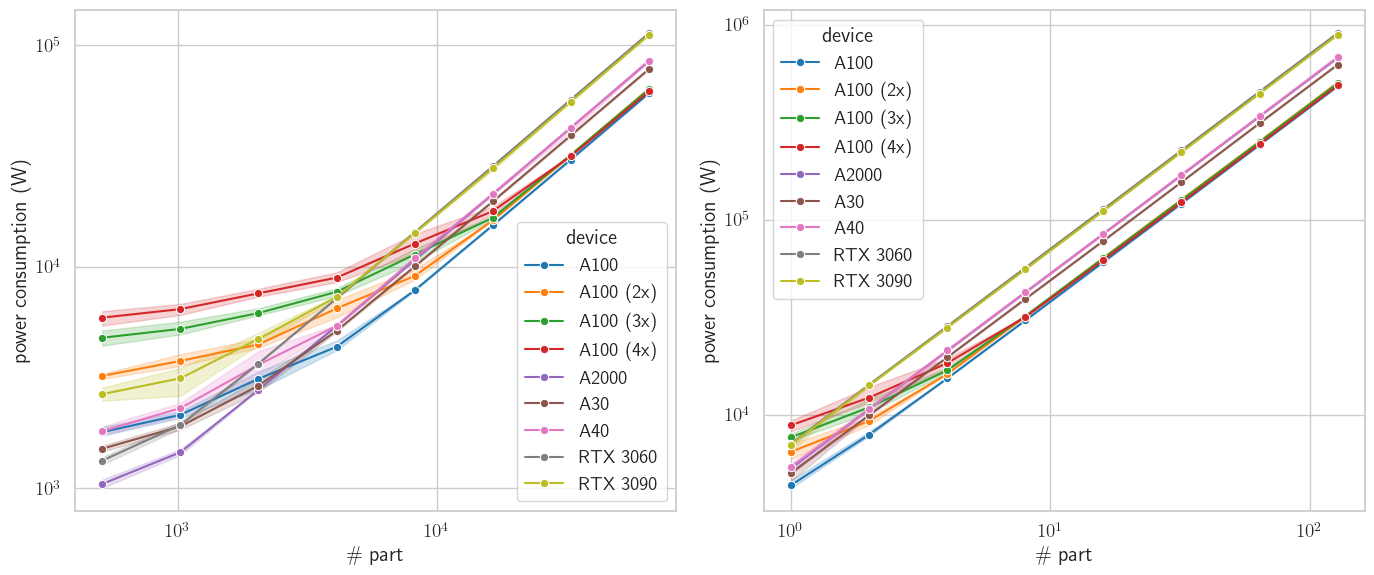

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.lineplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "part")'),
    x='val',
    y='power',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    markers='o',
    ax=ax[0],
)
ax1.set(xscale='log', yscale='log', xlabel=r'\# part', ylabel='power consumption (W)')

ax2 = sns.lineplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "k0")'),
    x='val',
    y='power',
    hue='device',
    marker='o',
    errorbar=('ci', 100),
    markers='o',
    ax=ax[1],
)
ax2.set(xscale='log', yscale='log', xlabel=r'\# part', ylabel='power consumption (W)')

[Text(0.5, 0, 'NGPU'), Text(0, 0.5, 'time (s)')]

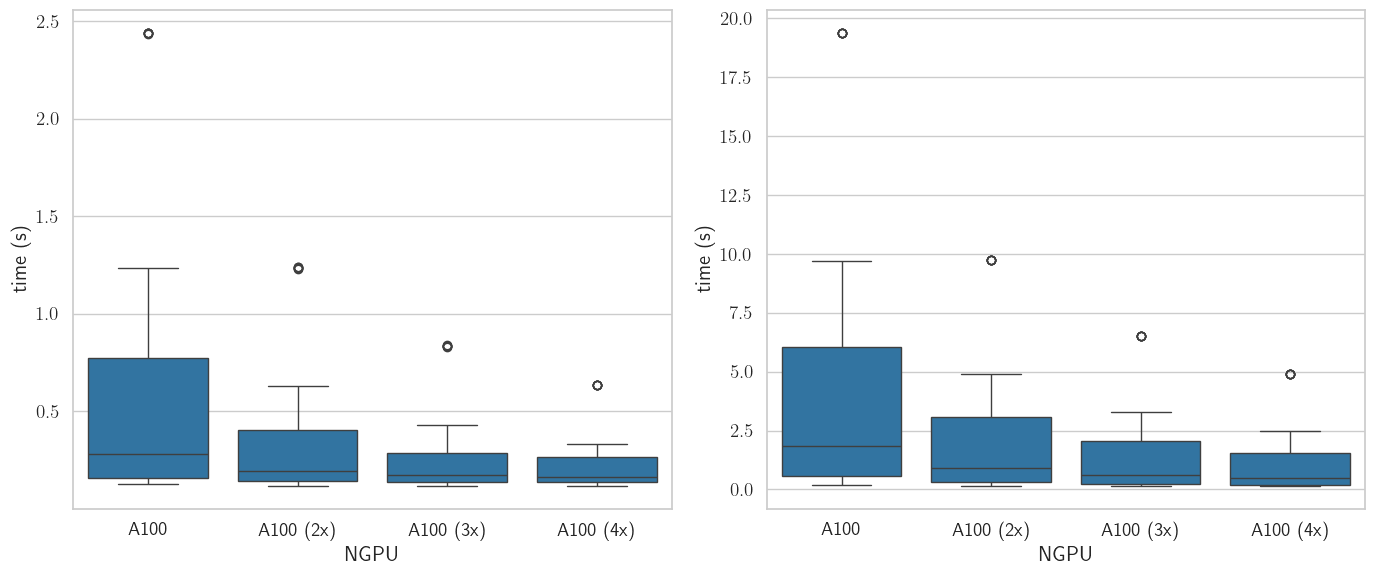

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), tight_layout=True)

ax1 = sns.boxplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "part") & (device.str.startswith("A100"))'),
    x='device',
    y='exetime',
    # hue='device',
    # marker='o',
    # errorbar=('ci', 100),
    # markers='o',
    ax=ax[0],
)
ax1.set(xlabel='NGPU', ylabel='time (s)')

ax2 = sns.boxplot(
    data=df.query('(version == "V8") & (date == 20111116) & (test == "k0") & (device.str.startswith("A100"))'),
    x='device',
    y='exetime',
    # hue='device',
    # marker='o',
    # errorbar=('ci', 100),
    # markers='o',
    ax=ax[1],
)
ax2.set(xlabel='NGPU', ylabel='time (s)')